In [19]:
# importing libraries
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [20]:
# importing data
chemicals_water = pd.read_csv('../data/Waterbase_data.csv')
chemicals_water.head()

,countryCode,waterBodyIdentifier,waterBodyIdentifierScheme,parameterWaterBodyCategory,observedPropertyDeterminandCode,observedPropertyDeterminandLabel,procedureAnalysedMatrix,resultUom,phenomenonTimeReferenceYear,parameterSamplingPeriod,...,resultNumberOfSitesClass4,resultNumberOfSitesClass5,resultObservationStatus,remarks,metadata_versionId,metadata_beginLifeSpanVersion,metadata_statusCode,metadata_observationStatus,metadata_statements,UID
0,BG,BG096,eionetGroundWaterBodyCode,GW,CAS_14797-65-0,Nitrite,W,mg{NO2}/L,1991,1991-01-01--1991-12-31,...,1.0,1.0,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,NOTE_LEGACY: The resultNumberOfSamples changed...,2667
1,FI,FI016,eionetGroundWaterBodyCode,GW,CAS_14797-65-0,Nitrite,W,mg{NO2}/L,2009,2009-01-01--2009-12-31,...,0.0,0.0,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,QC_LOQ_BELOW_MIN_NONESSENTIAL: Possible LOQ ou...,12234
2,BG,BG3G000000Q010,euGroundWaterBodyCode,GW,EEA_3132-01-2,Dissolved oxygen,W,mg/L,2002,2002-01-01--2002-12-31,...,NaN,NaN,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,NOTE_LEGACY: The resultNumberOfSamples changed...,4282
3,FI,FI034,eionetGroundWaterBodyCode,GW,EEA_3132-01-2,Dissolved oxygen,W,mg/L,1989,1989-01-01--1989-12-31,...,NaN,NaN,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,NOTE_LEGACY: The resultNumberOfSamples changed...,13263
4,FI,FI016,eionetGroundWaterBodyCode,GW,CAS_14797-65-0,Nitrite,W,mg{NO2}/L,2010,2010-01-01--2010-12-31,...,0.0,0.0,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,QC_LOQ_BELOW_MIN_NONESSENTIAL: Possible LOQ ou...,12235


In [21]:
# numerical and categorical columns 
cat_cols = chemicals_water.select_dtypes(object).columns
num_cols = chemicals_water.select_dtypes(np.number).columns

# prinitng numerical columns
print("Dataset has following Numerical columns")
for i, j in enumerate(num_cols):
    print(f" {i+1}) {j}")

# printing categorical columns
print("\n\nDataset has following Categorical columns")
for i, j in enumerate(cat_cols):
    print(f" {i+1}) {j}")

Dataset has following Numerical columns
 1) phenomenonTimeReferenceYear
 2) procedureLOQValue
 3) resultNumberOfSamples
 4) resultQualityNumberOfSamplesBelowLOQ
 5) resultQualityMinimumBelowLOQ
 6) resultMinimumValue
 7) resultQualityMeanBelowLOQ
 8) resultMeanValue
 9) resultQualityMaximumBelowLOQ
 10) resultMaximumValue
 11) resultQualityMedianBelowLOQ
 12) resultMedianValue
 13) resultStandardDeviationValue
 14) resultNumberOfSitesClass1
 15) resultNumberOfSitesClass2
 16) resultNumberOfSitesClass3
 17) resultNumberOfSitesClass4
 18) resultNumberOfSitesClass5
 19) UID


Dataset has following Categorical columns
 1) countryCode
 2) waterBodyIdentifier
 3) waterBodyIdentifierScheme
 4) parameterWaterBodyCategory
 5) observedPropertyDeterminandCode
 6) observedPropertyDeterminandLabel
 7) procedureAnalysedMatrix
 8) resultUom
 9) parameterSamplingPeriod
 10) resultObservationStatus
 11) remarks
 12) metadata_versionId
 13) metadata_beginLifeSpanVersion
 14) metadata_statusCode
 15) met

In [22]:
# checking for duplicate Rows
print(chemicals_water[chemicals_water.duplicated()])

Empty DataFrame
Columns: [countryCode, waterBodyIdentifier, waterBodyIdentifierScheme, parameterWaterBodyCategory, observedPropertyDeterminandCode, observedPropertyDeterminandLabel, procedureAnalysedMatrix, resultUom, phenomenonTimeReferenceYear, parameterSamplingPeriod, procedureLOQValue, resultNumberOfSamples, resultQualityNumberOfSamplesBelowLOQ, resultQualityMinimumBelowLOQ, resultMinimumValue, resultQualityMeanBelowLOQ, resultMeanValue, resultQualityMaximumBelowLOQ, resultMaximumValue, resultQualityMedianBelowLOQ, resultMedianValue, resultStandardDeviationValue, resultNumberOfSitesClass1, resultNumberOfSitesClass2, resultNumberOfSitesClass3, resultNumberOfSitesClass4, resultNumberOfSitesClass5, resultObservationStatus, remarks, metadata_versionId, metadata_beginLifeSpanVersion, metadata_statusCode, metadata_observationStatus, metadata_statements, UID]
Index: []

[0 rows x 35 columns]


In [23]:
# checking and handling missing values 
for column in chemicals_water.columns:
    print(f"Null Values in column '{column}' are: ", chemicals_water[column].isnull().sum())

Null Values in column 'countryCode' are:  0
Null Values in column 'waterBodyIdentifier' are:  0
Null Values in column 'waterBodyIdentifierScheme' are:  0
Null Values in column 'parameterWaterBodyCategory' are:  0
Null Values in column 'observedPropertyDeterminandCode' are:  0
Null Values in column 'observedPropertyDeterminandLabel' are:  0
Null Values in column 'procedureAnalysedMatrix' are:  0
Null Values in column 'resultUom' are:  0
Null Values in column 'phenomenonTimeReferenceYear' are:  0
Null Values in column 'parameterSamplingPeriod' are:  238
Null Values in column 'procedureLOQValue' are:  90
Null Values in column 'resultNumberOfSamples' are:  0
Null Values in column 'resultQualityNumberOfSamplesBelowLOQ' are:  82
Null Values in column 'resultQualityMinimumBelowLOQ' are:  18224
Null Values in column 'resultMinimumValue' are:  899
Null Values in column 'resultQualityMeanBelowLOQ' are:  18224
Null Values in column 'resultMeanValue' are:  7
Null Values in column 'resultQualityMax

In [24]:
# dropping missing values 
chemicals_clean = chemicals_water.dropna(subset=[
    'countryCode',
    'observedPropertyDeterminandLabel',
    'phenomenonTimeReferenceYear',
    'resultMeanValue'
])

# filtering years >=2000 for 'recent' water quality data
chemicals_clean = chemicals_clean[
    chemicals_clean['phenomenonTimeReferenceYear'] >= 2000
]

chemicals = chemicals_clean[[
    'countryCode',
    'observedPropertyDeterminandLabel',
    'phenomenonTimeReferenceYear',
    'resultMeanValue'
]]

# new look at data
chemicals.sample(8)

,countryCode,observedPropertyDeterminandLabel,phenomenonTimeReferenceYear,resultMeanValue
10103,BG,Nitrate,2004,10.204
2464,FI,Nitrate,2011,0.290
12766,ES,Ammonium,2008,0.040
7162,LI,Ammonium,2001,0.005
18099,ES,Ammonium,2012,0.100
19246,ES,Nitrate,2006,1.000
5605,BG,Nitrate,2001,30.165
15891,BE,Nitrate,2010,56.890


In [25]:
# dropping missing values in selected columns
water_clean = chemicals.dropna(subset=[
    'countryCode',
    'observedPropertyDeterminandLabel',
    'phenomenonTimeReferenceYear',
    'resultMeanValue'
])

# display sorted list of country codes in the dataset
sorted(water_clean['countryCode'].unique())

['AL',
 'BE',
 'BG',
 'CY',
 'EE',
 'ES',
 'FI',
 'HU',
 'IT',
 'LI',
 'LT',
 'LU',
 'LV',
 'ME',
 'MT',
 'NL',
 'NO',
 'PL',
 'RO',
 'SE',
 'SK',
 'TR']

In [26]:
# renaming 'countryCode' to respective country name
countries = {
    'AL': 'Albania',
    'BE': 'Belgium',
    'BG': 'Bulgaria',
    'CY': 'Cyprus',
    'EE': 'Estonia',
    'ES': 'Spain',
    'FI': 'Finland',
    'HU': 'Hungary',
    'IT': 'Italy',
    'LI': 'Liechtenstein',
    'LT': 'Lithuania',
    'LU': 'Luxembourg',
    'LV': 'Latvia',
    'ME': 'Montenegro',
    'MT': 'Malta',
    'NL': 'Netherlands',
    'NO': 'Norway', 
    'PL': 'Poland',
    'RO': 'Romania',
    'SE': 'Sweden',
    'SK': 'Slovakia',
    'TR': 'Turkey',
    
}
water_clean['countryCode'] = water_clean['countryCode'].replace(countries)

# renaming column 'countryCode' to 'Country'
water_clean.rename(columns={'countryCode': 'Country'}, inplace=True)

# new look at data
water_clean.head

<bound method NDFrame.head of         Country observedPropertyDeterminandLabel  phenomenonTimeReferenceYear  \
1       Finland                          Nitrite                         2009   
2      Bulgaria                 Dissolved oxygen                         2002   
4       Finland                          Nitrite                         2010   
7      Bulgaria                          Nitrite                         2001   
8       Finland                 Dissolved oxygen                         2004   
...         ...                              ...                          ...   
20778   Romania                         Ammonium                         2018   
20779   Romania                         Ammonium                         2019   
20780   Romania                         Ammonium                         2019   
20781   Romania                         Ammonium                         2021   
20782   Romania                         Ammonium                         2021  

In [27]:
# saving clean dataset
water_clean.to_csv('../data/water_cleaned.csv', index=False)

In [28]:
# filtering data for the Netherlands
nl_water = water_clean[water_clean['Country'] == 'Netherlands']

Total unique values are:  2 


Category	Value

observedPropertyDeterminandLabel
Ammonium    136
Nitrate     136
Name: count, dtype: int64


c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead



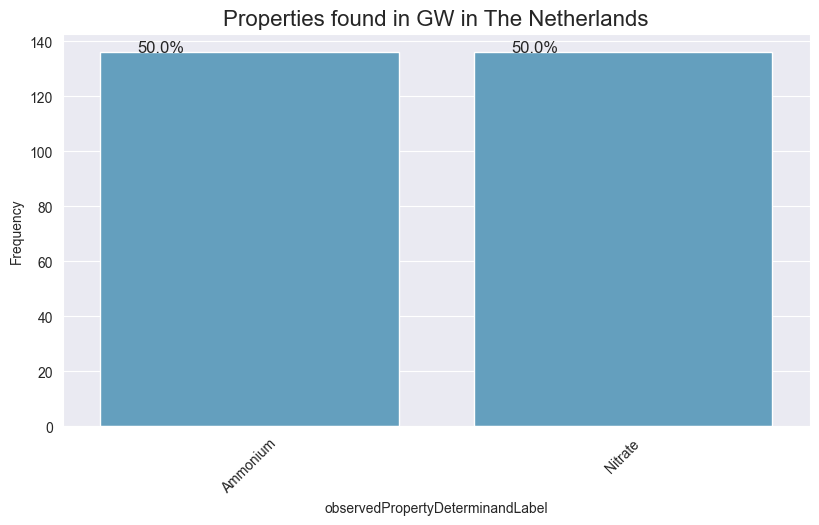

In [29]:
# frequency of property observations
def plot_category_dist(feature, title="", limited=False, n=10):
    print("Total unique values are: ", len(feature.value_counts()), "\n\n")
    print("Category\tValue\n")
    if limited:
        data = feature.value_counts()[0:n]
    else:
        data = feature.value_counts()
    print(data)
    categories_num = len(data)
    
    # plotting properties 
    sns.set_style('darkgrid')
    plt.figure(figsize=(16,5))
    plt.subplot(1,2,1)
    plt.title(title, fontsize=16)
    plt.xlabel("Property")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plot = sns.barplot(x=data.index, y=data.values, edgecolor="white", color=sns.color_palette("icefire")[0])

    total = len(feature)
    for p in plot.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.3
        y = p.get_y() + p.get_height()
        plot.annotate(percentage, (x, y), size = 12)

plot_category_dist(nl_water['observedPropertyDeterminandLabel'],f"Properties found in GW in The Netherlands")

In [30]:
def plot_chemical_trend(df, country, chemical, min_year=2000):
    # filtering data
    subset = df[
        (df['Country'] == country) & 
        (df['observedPropertyDeterminandLabel'] == chemical) &
        (df['phenomenonTimeReferenceYear'] >= min_year)
    ]

    # group by year and sum concentrations
    grouped = subset.groupby('phenomenonTimeReferenceYear')['resultMeanValue'].sum().reset_index()

    # making plot
    fig = px.bar(
        grouped,
        x='phenomenonTimeReferenceYear',
        y='resultMeanValue',
        title=f'Historical {chemical} Concentration in GW Bodies in {country}',
        labels={
            'phenomenonTimeReferenceYear': 'Year',
            'resultMeanValue': 'Total Concentration (mg/L)'
        },
        text_auto='.2s'
    )

    fig.update_traces(marker_color='#512E5F', textposition='outside')
    fig.update_layout(title_font_size=18, xaxis_tickangle=-45, bargap=0.2, margin=dict(t=100))
    fig.show()

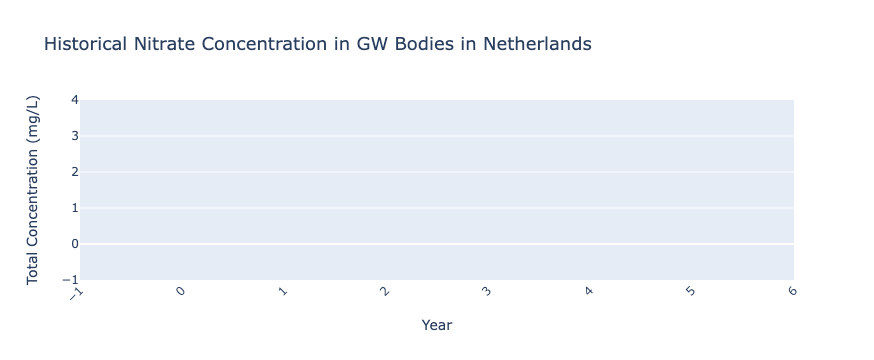

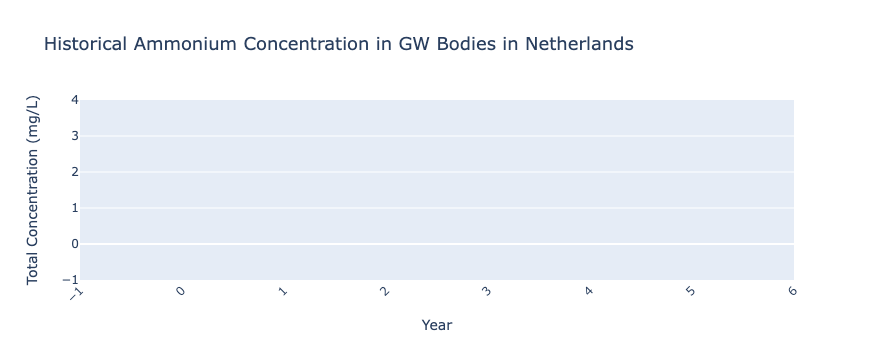

In [31]:
# plotting trends
plot_chemical_trend(
    df=water_clean,
    country='Netherlands',
    chemical='Nitrate',
    min_year=2000
)

plot_chemical_trend(
    df=water_clean,
    country='Netherlands',
    chemical='Ammonium',
    min_year=2000
)

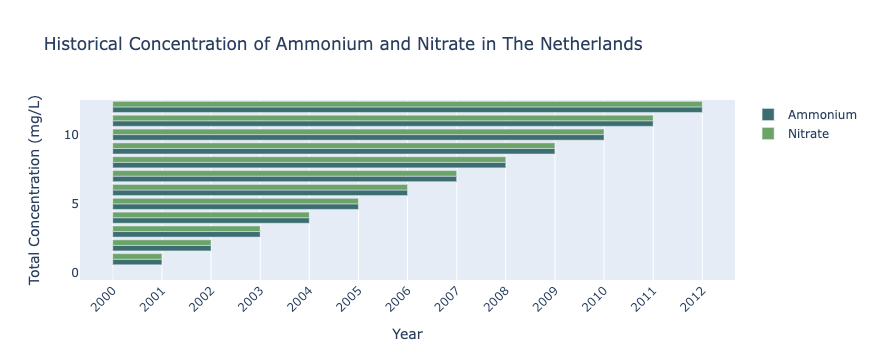

In [33]:
# https://plotly.com/python/bar-charts/

# filtering data for The Netherlands
nl_water = water_clean[water_clean['Country'] == 'Netherlands']

grouped = nl_water.groupby(['phenomenonTimeReferenceYear', 'observedPropertyDeterminandLabel'])['resultMeanValue'].sum().reset_index()
pivoted = grouped.pivot(index='phenomenonTimeReferenceYear', columns='observedPropertyDeterminandLabel', values='resultMeanValue').fillna(0)

# sort years
pivoted = pivoted.sort_index()

# data for plotting
years = pivoted.index.astype(str) 
ammonium = pivoted['Ammonium'] if 'Ammonium' in pivoted else [0]*len(years)
nitrate = pivoted['Nitrate'] if 'Nitrate' in pivoted else [0]*len(years)

# making plot
fig = go.Figure()
fig.add_trace(go.Bar(
    x=years,
    y=ammonium,
    name='Ammonium',
    marker_color='#3C6E71'
))
fig.add_trace(go.Bar(
    x=years,
    y=nitrate,
    name='Nitrate',
    marker_color='#6BA368'
))

fig.update_layout(
    title='Historical Concentration of Ammonium and Nitrate in The Netherlands',
    xaxis_title='Year',
    yaxis_title='Total Concentration (mg/L)',
    barmode='group',
    xaxis_tickangle=-45
)

fig.write_html("../visualizations/concentration_properties_GW_NL.html")
fig.show()